In [1]:
import sys
from pathlib import Path
import logging

import torch
import matplotlib.pyplot as plt 
import numpy as np

sys.path.append("../..")

from data_manager.h5datasets.paths2h5 import all_mc_path2h5, exp_path2h5
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader, h5py

import logging

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [18]:
import math

h_sat = 9
k = 30 / h_sat

print('h_saturate=%d, k=%.3f' % (h_sat, k))
print('%6s %8s %8s' % ('n_hits', 'linear', 'sigmoid'))
print('-' * 26)
for n in [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 12, 15, 20]:
    linear = min(1.0, n / h_sat)
    x = k * (n - h_sat / 2.0)
    sig = 1.0 / (1.0 + math.exp(-x))
    print('%6d %8.3f %8.3f' % (n, linear, sig))

h_saturate=9, k=3.333
n_hits   linear  sigmoid
--------------------------
     0    0.000    0.000
     1    0.111    0.000
     2    0.222    0.000
     3    0.333    0.007
     4    0.444    0.159
     5    0.556    0.841
     6    0.667    0.993
     7    0.778    1.000
     8    0.889    1.000
    10    1.000    1.000
    12    1.000    1.000
    15    1.000    1.000
    20    1.000    1.000


2025-10-07 20:07:48,370 - INFO - Lazy range loading for exp: 1000 events loaded (range 600000-601000)
2025-10-07 20:07:49,472 - INFO - Loaded 1000 events for exp
2025-10-07 20:07:49,475 - INFO - Loaded 1000 events from exp (neutrino=False)
2025-10-07 20:07:49,477 - INFO - Interleaved 0 neutrino and 1000 muon events for balanced batches
2025-10-07 20:07:49,627 - INFO - Loaded 1000 events from 1 particle types
2025-10-07 20:07:49,629 - INFO - Neutrino events: 0, Muon events: 1000


['exp:part_s2020_c07']


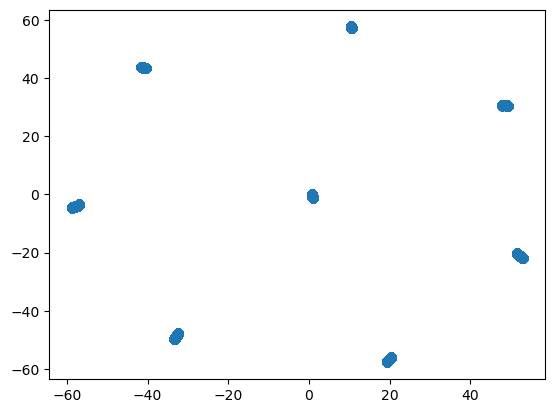

In [ ]:
# ds = BaikalMCDataset(
#     all_mc_path2h5,
#     events_per_particle={"muatm_2020": 500_000, 'nuatm_2020': 250_000, 'nue2_2020': 250_000},
#     )

ds = NuMuDataset(
    exp_path2h5,
    particle_types=['exp'],
    neutrino_types=[],
    events_per_particle={"exp": 100_000},
    sampling_config={'exp': {'mode': 'range', 'start_event': 600_000}},
    shuffle_events=False
    )

coords = []
ids = []
for i in range(len(ds)):
    #print(ds.get_event_with_id(i)[2])
    data, label, id_str = ds.get_event_with_id(i)
    coords.append(data[:,2:5].numpy())
    ids.append(id_str)
    

coords_all = np.concatenate(coords, axis=0)
print(np.unique(['_'.join(s.split('_')[0:3]) for s in ids]))
plt.plot(coords_all[:,0], coords_all[:,1], 'o')

2025-10-27 11:13:16,457 - INFO - Lazy range loading for muatm_2020: 10000 events loaded (range 100000-110000)
2025-10-27 11:13:16,846 - INFO - Loaded 10000 events for muatm_2020
2025-10-27 11:13:16,849 - INFO - Loaded 10000 events from muatm_2020 (neutrino=False)
2025-10-27 11:13:16,856 - INFO - Lazy range loading for nuatm_2020: 5000 events loaded (range 0-5000)


2025-10-27 11:13:17,222 - INFO - Loaded 5000 events for nuatm_2020
2025-10-27 11:13:17,224 - INFO - Loaded 5000 events from nuatm_2020 (neutrino=True)
2025-10-27 11:13:17,230 - INFO - Lazy range loading for nue2_2020: 5000 events loaded (range 0-5000)
2025-10-27 11:13:17,505 - INFO - Loaded 5000 events for nue2_2020
2025-10-27 11:13:17,506 - INFO - Loaded 5000 events from nue2_2020 (neutrino=True)
2025-10-27 11:13:17,519 - INFO - Shuffled 20000 events to remove particle-type ordering bias
2025-10-27 11:13:17,542 - INFO - Interleaved 10000 neutrino and 10000 muon events for balanced batches
2025-10-27 11:13:17,550 - INFO - Loaded 20000 events from 3 particle types
2025-10-27 11:13:17,551 - INFO - Neutrino events: 10000, Muon events: 10000


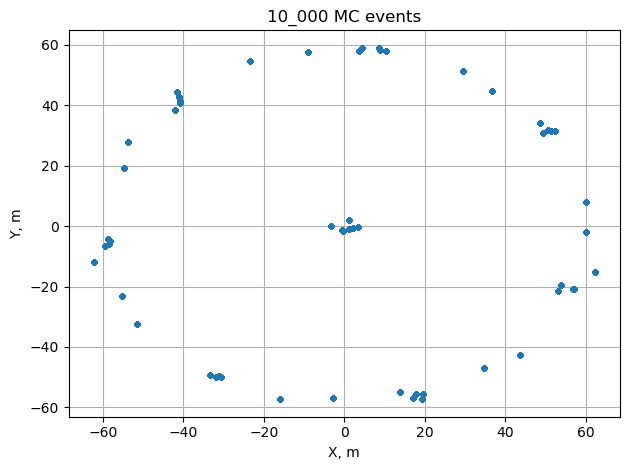

In [31]:
ds = NuMuDataset(
    all_mc_path2h5,
    events_per_particle={"muatm_2020": 10_000, 'nuatm_2020': 5000, 'nue2_2020': 5000},
    sampling_config={'muatm_2020': {'mode': 'range', 'start_event': 100_000},},
    shuffle_events=True
    )

coords_mu = []
coords_nu = []
ids = []
for i in range(10_000):
    #print(ds.get_event_with_id(i)[2])
    res = ds[i]
    data, label = res['features'], res['labels']
    if label:
        coords_nu.append(data[:,2:5].numpy())
    else:
        coords_mu.append(data[:,2:5].numpy())
coords_all_nu = np.concatenate(coords_nu, axis=0)
coords_all_mu = np.concatenate(coords_mu, axis=0)
# print(np.unique(['_'.join(s.split(':')[0:2]) for s in ids]))
plt.plot(coords_all_nu[:,0], coords_all_nu[:,1], '.')
#plt.plot(coords_all_mu[:,0], coords_all_mu[:,1], 'o')
plt.title("10_000 MC events")
plt.xlabel("X, m")
plt.ylabel("Y, m")
plt.grid()
plt.tight_layout()
plt.savefig("MC_XY.png")

In [17]:
import yaml

stats_default = yaml.safe_load(open("/home/albert/Baikal2025/data_manager/stats_dict/default_mc.yaml", 'r'))
augmentation_config = {"noise_std": [0.05, 5., 1., 1., 2.], "rotation_std": 1.}

dl = create_numu_dataloader(
    all_mc_path2h5, batch_size=1024, 
    shuffle=True,
    events_per_particle={"muatm_2020": 10_000, 'nuatm_2020': 5_000, 'nue2_2020': 5_000},
    particle_types = ['muatm_2020', 'nue2_2020', 'nuatm_2020'],
    neutrino_types=['nue2_2020', 'nuatm_2020'],
    shuffle_batch=True,
    normalization_config = None,
    augmentation_config = augmentation_config,
    use_polar_coords=False
    )

2025-10-27 11:10:25,551 - INFO - Lazy range loading for muatm_2020: 10000 events loaded (range 0-10000)
2025-10-27 11:10:25,947 - INFO - Loaded 10000 events for muatm_2020
2025-10-27 11:10:25,950 - INFO - Loaded 10000 events from muatm_2020 (neutrino=False)
2025-10-27 11:10:25,955 - INFO - Lazy range loading for nue2_2020: 5000 events loaded (range 0-5000)


2025-10-27 11:10:26,239 - INFO - Loaded 5000 events for nue2_2020
2025-10-27 11:10:26,241 - INFO - Loaded 5000 events from nue2_2020 (neutrino=True)
2025-10-27 11:10:26,249 - INFO - Lazy range loading for nuatm_2020: 5000 events loaded (range 0-5000)
2025-10-27 11:10:26,620 - INFO - Loaded 5000 events for nuatm_2020
2025-10-27 11:10:26,623 - INFO - Loaded 5000 events from nuatm_2020 (neutrino=True)
2025-10-27 11:10:26,636 - INFO - Shuffled 20000 events to remove particle-type ordering bias
2025-10-27 11:10:26,658 - INFO - Interleaved 10000 neutrino and 10000 muon events for balanced batches
2025-10-27 11:10:26,666 - INFO - Loaded 20000 events from 3 particle types
2025-10-27 11:10:26,668 - INFO - Neutrino events: 10000, Muon events: 10000


In [18]:
from tqdm import tqdm

x, y, z = [], [], []
polar_coords = []
for batch in tqdm(dl):
    mask = batch['mask']
    #print(batch['features'].shape, batch['labels'].shape)
    x.append(batch['features'][mask][:,2].numpy().flatten())
    y.append(batch['features'][mask][:,3].numpy().flatten())
    z.append(batch['features'][mask][:,4].numpy().flatten())
    #polar_coords.append(batch['features'][:,:,5:8].numpy())

100%|██████████| 20/20 [00:02<00:00,  7.28it/s]


In [19]:
x = np.concatenate(x)
y = np.concatenate(y)
z = np.concatenate(z)

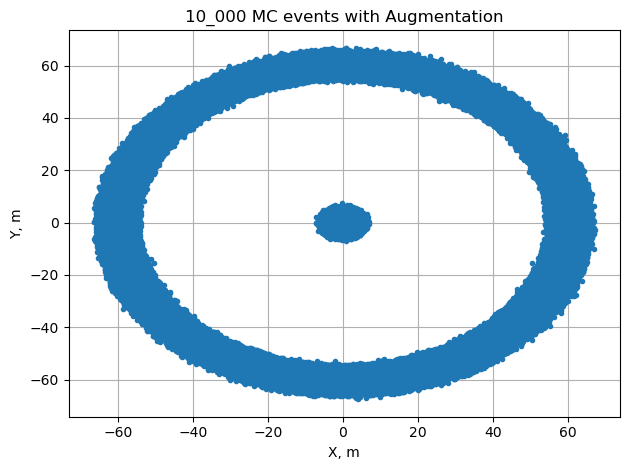

In [33]:
import matplotlib.pyplot as plt

plt.plot(x, y, '.')
plt.grid()
plt.title("10_000 MC events with Augmentation")
plt.xlabel("X, m")
plt.ylabel("Y, m")
plt.tight_layout()
plt.savefig("AugMC_XY.png")

In [29]:
np.unique(x[0:100_000]+y[0:100_000]).shape, x.shape

((56901,), (71466560,))

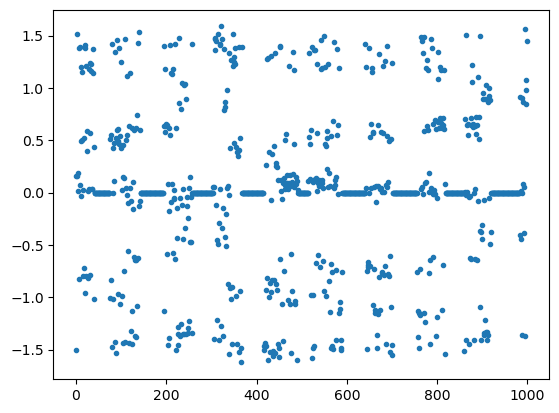

In [33]:
plt.plot(x[:1_000],'.')

In [27]:
x.shape[0]/3

23822186.666666668

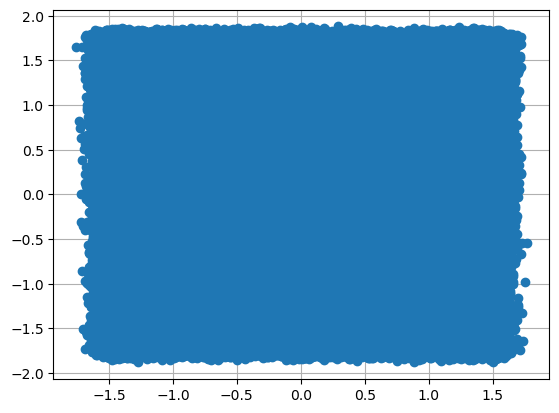

In [20]:
import matplotlib.pyplot as plt

plt.plot(x[::100],z[::100],'o')
plt.grid()

(array([ 922.,   25.,    0.,    0., 3834.,    0.,    0.,  739., 5815.,
         441.]),
 array([-0.99916095, -0.76498461, -0.53080833, -0.29663199, -0.06245571,
         0.17172056,  0.40589696,  0.64007324,  0.87424952,  1.10842586,
         1.34260201]),
 <BarContainer object of 10 artists>)

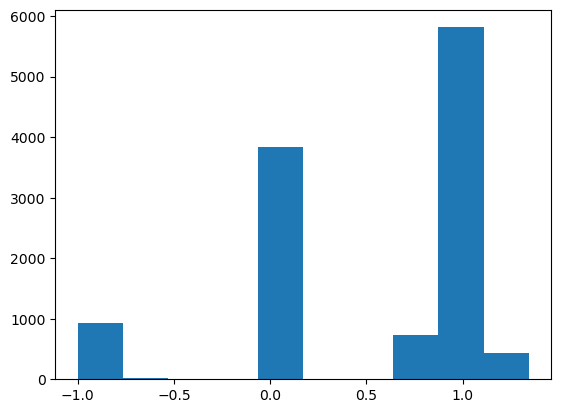

In [8]:
plt.hist(r)

In [16]:
import h5py

with h5py.File(exp_path2h5) as f:
    # keys = f['exp/clusters_centers/'].keys()
    # for k in keys:
    #     print(k)
    #     print('\t', f[f'exp/clusters_centers/{k}/data'][:])
    coords = f['exp/raw/data/part_s2020_c01_r0027/data'][:][:,2:]

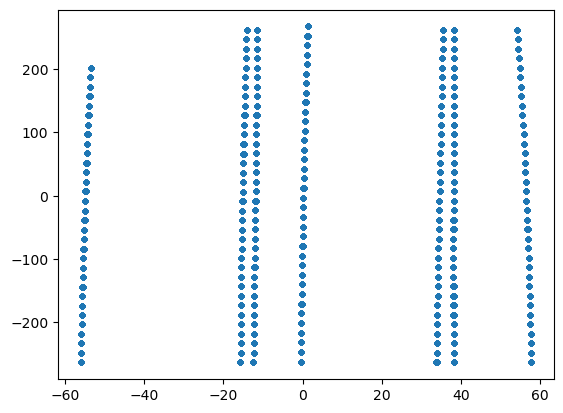

In [18]:
import matplotlib.pyplot as plt

plt.plot(coords[:,1], coords[:,2], '.')


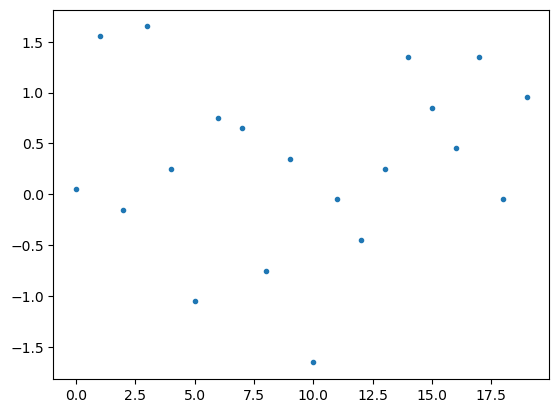

In [17]:
import matplotlib.pyplot as plt

plt.plot(batch['features'][3][:20, 4], '.')

In [10]:
import torch

torch.cuda.is_available()

torch.rand(5).to('cuda:1')

tensor([0.0251, 0.8419, 0.7465, 0.9455, 0.8648], device='cuda:1')

In [1]:
hours = int(input())
minutes = int(input())

if 0 <= hours < 24 and 0 <= minutes < 60:
    if hours < 12:    
        flag = "AM" 
    else:
        flag = "PM"

    if hours == 0:
        hour12 = 12
    elif hours > 12:
        hour12 = hours - 12
    else:
        hour12 = hours

    if hour12 < 10:
        hour_str = "0" + str(hour12)
    else:
        hour_str = str(hour12)

    if minutes < 10:
        minute_str = "0" + str(minutes)
    else:
        minute_str = str(minutes)

    print(hour_str + ":" + minute_str, flag)
else:
    print("ошибка")   


11:08 PM


In [ ]:
import numpy as np
from prefilter_npy_dataset import ExpDataset

ds = ExpDataset(
    h5_path='../../data_manager/data/h5datasets/exp.h5',
    max_events=100,
    seed=42,
)
train_ds, val_ds = ds.split(0.85, seed=42)

train_ids = set(train_ds.get_event_ids())
val_ids   = set(val_ds.get_event_ids())

print(f'Total:  {len(ds)}')
print(f'Train:  {len(train_ds)}  (expected ~850)')
print(f'Val:    {len(val_ds)}   (expected ~150)')
print(f'Overlap: {len(train_ids & val_ids)}  (expected 0)')

all_ids = ds.get_event_ids()
first_850_ids = set(all_ids[:850])
print(f'Train == first 850 events: {train_ids == first_850_ids}  (expected False)')

Total:  100
Train:  85  (expected ~850)
Val:    15   (expected ~150)
Overlap: 0  (expected 0)


AttributeError: 'set' object has no attribute 'sort'

In [23]:
train_ds._indices, val_ds._indices

(array([83, 53, 70, 45, 44, 39, 22, 80, 10,  0, 18, 30, 73, 33, 90,  4, 76,
        77, 12, 31, 55, 88, 26, 42, 69, 15, 40, 96,  9, 72, 11, 47, 85, 28,
        93,  5, 66, 65, 35, 16, 49, 34,  7, 95, 27, 19, 81, 25, 62, 13, 24,
         3, 17, 38,  8, 78,  6, 64, 36, 89, 56, 99, 54, 43, 50, 67, 46, 68,
        61, 97, 79, 41, 58, 48, 98, 57, 75, 32, 94, 59, 63, 84, 37, 29,  1]),
 array([52, 21,  2, 23, 87, 91, 74, 86, 82, 20, 60, 71, 14, 92, 51]))

In [19]:
set(train_ds.get_event_ids())

{'exp_s2020_c01_r0027_15153',
 'exp_s2020_c01_r0027_21093',
 'exp_s2020_c01_r0116_16432',
 'exp_s2020_c01_r0116_20527',
 'exp_s2020_c01_r0116_23096',
 'exp_s2020_c01_r0116_943',
 'exp_s2020_c01_r0188_17639',
 'exp_s2020_c01_r0188_18347',
 'exp_s2020_c02_r0015_14698',
 'exp_s2020_c02_r0015_2628',
 'exp_s2020_c02_r0015_4669',
 'exp_s2020_c02_r0015_4833',
 'exp_s2020_c02_r0149_15347',
 'exp_s2020_c02_r0149_2817',
 'exp_s2020_c02_r0206_10934',
 'exp_s2020_c02_r0206_12617',
 'exp_s2020_c02_r0206_18',
 'exp_s2020_c02_r0206_8901',
 'exp_s2020_c02_r0357_13177',
 'exp_s2020_c02_r0357_21409',
 'exp_s2020_c03_r0012_1321',
 'exp_s2020_c03_r0012_17484',
 'exp_s2020_c03_r0012_23772',
 'exp_s2020_c03_r0012_326',
 'exp_s2020_c03_r0012_5164',
 'exp_s2020_c03_r0012_7950',
 'exp_s2020_c03_r0115_16323',
 'exp_s2020_c03_r0115_17589',
 'exp_s2020_c03_r0115_18911',
 'exp_s2020_c03_r0115_5868',
 'exp_s2020_c03_r0263_14243',
 'exp_s2020_c03_r0263_17353',
 'exp_s2020_c03_r0263_4107',
 'exp_s2020_c03_r0263_7152'

In [20]:
set(val_ids)

{'exp_s2020_c01_r0027_24410',
 'exp_s2020_c02_r0149_6859',
 'exp_s2020_c02_r0206_19733',
 'exp_s2020_c02_r0206_20418',
 'exp_s2020_c02_r0357_18946',
 'exp_s2020_c04_r0116_18655',
 'exp_s2020_c04_r0116_7962',
 'exp_s2020_c05_r0116_4167',
 'exp_s2020_c05_r0377_22117',
 'exp_s2020_c06_r0032_10859',
 'exp_s2020_c06_r0134_20519',
 'exp_s2020_c06_r0325_16654',
 'exp_s2020_c06_r0325_16948',
 'exp_s2020_c07_r0041_15816',
 'exp_s2020_c07_r0120_1982'}

In [12]:
print(f'Train == first 850 events: {train_ids == first_850_ids}  (expected False)')

Train == first 850 events: False  (expected False)


In [13]:
first_850_ids

{'exp_s2020_c01_r0027_15153',
 'exp_s2020_c01_r0027_21093',
 'exp_s2020_c01_r0027_24410',
 'exp_s2020_c01_r0116_16432',
 'exp_s2020_c01_r0116_20527',
 'exp_s2020_c01_r0116_23096',
 'exp_s2020_c01_r0116_943',
 'exp_s2020_c01_r0188_17639',
 'exp_s2020_c01_r0188_18347',
 'exp_s2020_c02_r0015_14698',
 'exp_s2020_c02_r0015_2628',
 'exp_s2020_c02_r0015_4669',
 'exp_s2020_c02_r0015_4833',
 'exp_s2020_c02_r0149_15347',
 'exp_s2020_c02_r0149_2817',
 'exp_s2020_c02_r0149_6859',
 'exp_s2020_c02_r0206_10934',
 'exp_s2020_c02_r0206_12617',
 'exp_s2020_c02_r0206_18',
 'exp_s2020_c02_r0206_19733',
 'exp_s2020_c02_r0206_20418',
 'exp_s2020_c02_r0206_8901',
 'exp_s2020_c02_r0357_13177',
 'exp_s2020_c02_r0357_18946',
 'exp_s2020_c02_r0357_21409',
 'exp_s2020_c03_r0012_1321',
 'exp_s2020_c03_r0012_17484',
 'exp_s2020_c03_r0012_23772',
 'exp_s2020_c03_r0012_326',
 'exp_s2020_c03_r0012_5164',
 'exp_s2020_c03_r0012_7950',
 'exp_s2020_c03_r0115_16323',
 'exp_s2020_c03_r0115_17589',
 'exp_s2020_c03_r0115_1891

In [9]:
train_ids

{'exp_s2020_c01_r0027_10009',
 'exp_s2020_c01_r0027_10545',
 'exp_s2020_c01_r0027_12259',
 'exp_s2020_c01_r0027_13201',
 'exp_s2020_c01_r0027_13625',
 'exp_s2020_c01_r0027_14283',
 'exp_s2020_c01_r0027_14403',
 'exp_s2020_c01_r0027_14640',
 'exp_s2020_c01_r0027_14904',
 'exp_s2020_c01_r0027_15125',
 'exp_s2020_c01_r0027_15153',
 'exp_s2020_c01_r0027_15388',
 'exp_s2020_c01_r0027_17659',
 'exp_s2020_c01_r0027_18464',
 'exp_s2020_c01_r0027_18485',
 'exp_s2020_c01_r0027_18967',
 'exp_s2020_c01_r0027_19318',
 'exp_s2020_c01_r0027_21093',
 'exp_s2020_c01_r0027_2130',
 'exp_s2020_c01_r0027_21456',
 'exp_s2020_c01_r0027_22450',
 'exp_s2020_c01_r0027_2310',
 'exp_s2020_c01_r0027_24113',
 'exp_s2020_c01_r0027_2436',
 'exp_s2020_c01_r0027_24410',
 'exp_s2020_c01_r0027_2460',
 'exp_s2020_c01_r0027_2684',
 'exp_s2020_c01_r0027_313',
 'exp_s2020_c01_r0027_3537',
 'exp_s2020_c01_r0027_4523',
 'exp_s2020_c01_r0027_4759',
 'exp_s2020_c01_r0027_5064',
 'exp_s2020_c01_r0027_5798',
 'exp_s2020_c01_r0027_

In [5]:
train_ids

{'exp_s2020_c01_r0027_10009',
 'exp_s2020_c01_r0027_10545',
 'exp_s2020_c01_r0027_12259',
 'exp_s2020_c01_r0027_13201',
 'exp_s2020_c01_r0027_13625',
 'exp_s2020_c01_r0027_14283',
 'exp_s2020_c01_r0027_14403',
 'exp_s2020_c01_r0027_14640',
 'exp_s2020_c01_r0027_14904',
 'exp_s2020_c01_r0027_15125',
 'exp_s2020_c01_r0027_15153',
 'exp_s2020_c01_r0027_15388',
 'exp_s2020_c01_r0027_17659',
 'exp_s2020_c01_r0027_18464',
 'exp_s2020_c01_r0027_18485',
 'exp_s2020_c01_r0027_18967',
 'exp_s2020_c01_r0027_19318',
 'exp_s2020_c01_r0027_21093',
 'exp_s2020_c01_r0027_2130',
 'exp_s2020_c01_r0027_21456',
 'exp_s2020_c01_r0027_22450',
 'exp_s2020_c01_r0027_2310',
 'exp_s2020_c01_r0027_24113',
 'exp_s2020_c01_r0027_2436',
 'exp_s2020_c01_r0027_24410',
 'exp_s2020_c01_r0027_2460',
 'exp_s2020_c01_r0027_2684',
 'exp_s2020_c01_r0027_313',
 'exp_s2020_c01_r0027_3537',
 'exp_s2020_c01_r0027_4523',
 'exp_s2020_c01_r0027_4759',
 'exp_s2020_c01_r0027_5064',
 'exp_s2020_c01_r0027_5798',
 'exp_s2020_c01_r0027_